# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/intermim/` de los datos de entrenamiento
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

# 1. Carga de datos

In [ ]:
import pandas as pd

housing = pd.read_csv("../data/interim/train_set.csv")

# 2. Inspección

## 2.1 Exploración Inicial

In [ ]:
print("Head:")
display(housing.head())
print("\n")

print("Info:")
display(housing.info(show_counts=True))
print("\n")

print("Sample:")
display(housing.sample(5, random_state=1))
print("\n")

Head:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY
1,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN
2,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND
3,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND
4,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN




Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16512 entries, 0 to 16511
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16344 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   median_house_value  16512 non-null  float64
 9   ocean_proximity     16512 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.3+ MB


None



Sample:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
11418,-118.21,34.18,14.0,2672.0,335.0,1113.0,318.0,12.1579,500001.0,<1H OCEAN
6821,-122.01,37.57,14.0,16199.0,2993.0,8117.0,2847.0,5.8322,281800.0,NEAR BAY
9138,-117.12,32.96,15.0,2869.0,405.0,1526.0,402.0,6.0175,238300.0,<1H OCEAN
4175,-117.57,34.07,4.0,2152.0,580.0,1083.0,441.0,3.1458,118800.0,INLAND
15220,-121.35,38.03,16.0,3158.0,515.0,1596.0,528.0,4.1739,131300.0,INLAND


In [ ]:
for col in housing.columns:
    display(housing[col].describe())

count    16512.000000
mean      -119.573125
std          2.000624
min       -124.350000
25%       -121.800000
50%       -118.510000
75%       -118.010000
max       -114.490000
Name: longitude, dtype: float64

count    16512.000000
mean        35.637746
std          2.133294
min         32.550000
25%         33.930000
50%         34.260000
75%         37.720000
max         41.950000
Name: latitude, dtype: float64

count    16512.000000
mean        28.577156
std         12.585738
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: housing_median_age, dtype: float64

count    16512.000000
mean      2639.402798
std       2185.287466
min          2.000000
25%       1447.000000
50%       2125.000000
75%       3154.000000
max      39320.000000
Name: total_rooms, dtype: float64

count    16344.000000
mean       538.949094
std        423.862079
min          1.000000
25%        296.000000
50%        434.000000
75%        645.000000
max       6210.000000
Name: total_bedrooms, dtype: float64

count    16512.000000
mean      1425.513929
std       1094.795467
min          3.000000
25%        787.000000
50%       1167.000000
75%       1726.000000
max      16305.000000
Name: population, dtype: float64

count    16512.000000
mean       499.990189
std        382.865787
min          1.000000
25%        279.000000
50%        408.000000
75%        603.000000
max       5358.000000
Name: households, dtype: float64

count    16512.000000
mean         3.870428
std          1.891936
min          0.499900
25%          2.562500
50%          3.538500
75%          4.750000
max         15.000100
Name: median_income, dtype: float64

count     16512.000000
mean     206333.518653
std      115314.047529
min       14999.000000
25%      119200.000000
50%      179200.000000
75%      263925.000000
max      500001.000000
Name: median_house_value, dtype: float64

count         16512
unique            5
top       <1H OCEAN
freq           7274
Name: ocean_proximity, dtype: object

In [ ]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     7274
INLAND        5301
NEAR OCEAN    2089
NEAR BAY      1846
ISLAND           2
Name: count, dtype: int64

Todas las columnas parecen mantener una estructura adecuada, con variables numéricas adecuadamente con tipo float64 y un campo categórico correspondiente a `ocean_proximity`. Solo `total_bedrooms` evidencia valores nulos.

## 2.2 Calidad de Datos

### 2.2.1 Completitud

In [ ]:
null_summary = []

for col in housing.columns:
    null_count = housing[col].isna().sum()
    if null_count > 0:
        null_summary.append({
            "column": col,
            "num_nulls": null_count,
            "percent_nulls": str(f"{null_count / len(housing) * 100:.2f}") + "%"
        })

null_summary = pd.DataFrame(null_summary)
display(null_summary)

,column,num_nulls,percent_nulls
0,total_bedrooms,168,1.02%


In [ ]:
null_total_bedrooms = housing[housing["total_bedrooms"].isna()]
display(housing.describe())
display(null_total_bedrooms.describe())
display(housing.describe().iloc[1:]-null_total_bedrooms.describe().iloc[1:])

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16344.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.573125,35.637746,28.577156,2639.402798,538.949094,1425.513929,499.990189,3.870428,206333.518653
std,2.000624,2.133294,12.585738,2185.287466,423.862079,1094.795467,382.865787,1.891936,115314.047529
min,-124.350000,32.550000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.000000,296.000000,787.000000,279.000000,2.562500,119200.000000
50%,-118.510000,34.260000,29.000000,2125.000000,434.000000,1167.000000,408.000000,3.538500,179200.000000
75%,-118.010000,37.720000,37.000000,3154.000000,645.000000,1726.000000,603.000000,4.750000,263925.000000
max,-114.490000,41.950000,52.000000,39320.000000,6210.000000,16305.000000,5358.000000,15.000100,500001.000000


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,168.000000,168.000000,168.000000,168.000000,0.0,168.000000,168.000000,168.000000,168.000000
mean,-119.510774,35.575774,28.833333,2488.708333,NaN,1444.214286,505.690476,3.715555,198711.339286
std,1.994297,2.100587,12.189947,1773.844464,NaN,1047.603231,403.946845,1.934817,110405.271434
min,-124.130000,32.660000,4.000000,154.000000,NaN,37.000000,16.000000,0.852700,45800.000000
25%,-121.790000,33.975000,18.000000,1277.250000,NaN,772.500000,254.750000,2.517550,117525.000000
50%,-118.550000,34.250000,29.500000,2022.500000,NaN,1138.500000,404.500000,3.310350,170850.000000
75%,-118.065000,37.582500,38.000000,3345.000000,NaN,1870.250000,627.500000,4.368775,259525.000000
max,-114.590000,40.920000,52.000000,11709.000000,NaN,7604.000000,3589.000000,15.000100,500001.000000


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
mean,-0.062351,0.061973,-0.256177,150.694465,NaN,-18.700356,-5.700287,0.154873,7622.179367
std,0.006327,0.032706,0.395791,411.443002,NaN,47.192237,-21.081058,-0.042881,4908.776094
min,-0.220000,-0.110000,-3.000000,-152.000000,NaN,-34.000000,-15.000000,-0.352800,-30801.000000
25%,-0.010000,-0.045000,0.000000,169.750000,NaN,14.500000,24.250000,0.044950,1675.000000
50%,0.040000,0.010000,-0.500000,102.500000,NaN,28.500000,3.500000,0.228150,8350.000000
75%,0.055000,0.137500,-1.000000,-191.000000,NaN,-144.250000,-24.500000,0.381225,4400.000000
max,0.100000,1.030000,0.000000,27611.000000,NaN,8701.000000,1769.000000,0.000000,0.000000


El dataset presenta alta completitud general, solo con `total_bedrooms` mostrando el 1% de sus datos faltantes. No se evidencia un patrón por lo que parece ser completamente aleatorio el motivo de los faltantes, por lo que se recomienda imputación con un valor por defecto.

### 2.2.2 Precisión

In [ ]:
housing.duplicated().sum()

np.int64(0)

No se evidencian filas duplicadas. Así mismo, no se consideran posibles duplicados lógicos ya que no se cuenta con una llave de negocio única (por ejemplo, ID de vivienda o de transacción) que permita identificar duplicados semánticos con certeza.

### 2.2.3 Sensibilidad

Resumen de sensibilidad (outliers por IQR):


,column,min,p01,p99,max,iqr_lower,iqr_upper,num_outliers,pct_outliers
4,total_bedrooms,1.0000,38.0000,2250.710000,6210.0000,-227.50000,1168.50000,1048,6.41%
3,total_rooms,2.0000,175.1100,11226.390000,39320.0000,-1113.50000,5714.50000,1041,6.3%
6,households,1.0000,32.0000,1985.890000,5358.0000,-207.00000,1089.00000,995,6.03%
5,population,3.0000,89.0000,5801.470000,16305.0000,-621.50000,3134.50000,969,5.87%
8,median_house_value,14999.0000,50000.0000,500001.000000,500001.0000,-97887.50000,481012.50000,862,5.22%
7,median_income,0.4999,1.0714,10.593209,15.0001,-0.71875,8.03125,537,3.25%
0,longitude,-124.3500,-123.2000,-116.290000,-114.4900,-127.48500,-112.32500,0,0.0%
1,latitude,32.5500,32.6800,40.600000,41.9500,28.24500,43.40500,0,0.0%
2,housing_median_age,1.0000,4.0000,52.000000,52.0000,-10.50000,65.50000,0,0.0%


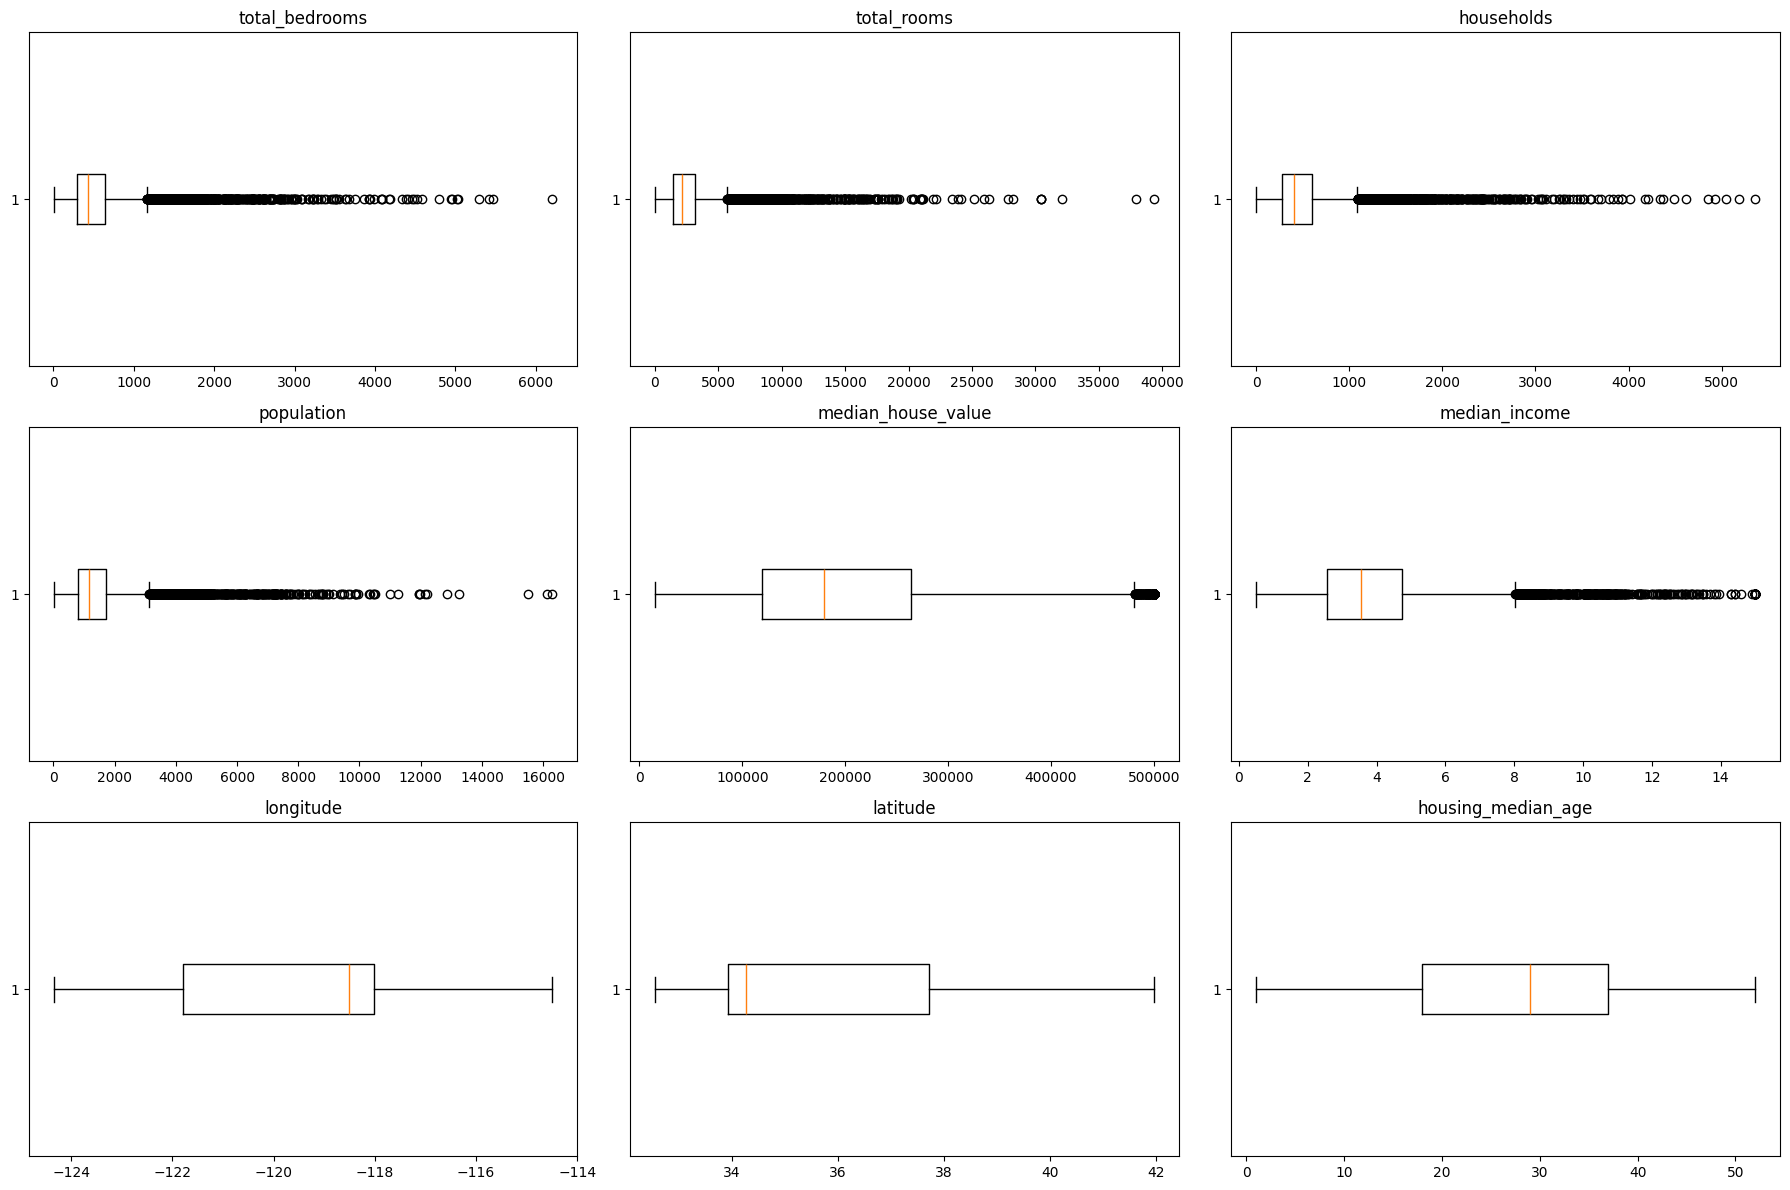

In [ ]:
# Variables numéricas para análisis de sensibilidad
numeric_cols = housing.select_dtypes(include="number").columns
sensitivity_summary = []

for col in numeric_cols:
    series = housing[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = series[(series < lower) | (series > upper)]

    sensitivity_summary.append({
        "column": col,
        "min": series.min(),
        "p01": series.quantile(0.01),
        "p99": series.quantile(0.99),
        "max": series.max(),
        "iqr_lower": lower,
        "iqr_upper": upper,
        "num_outliers": int(outliers.shape[0]),
        "pct_outliers": round(outliers.shape[0] / series.shape[0] * 100, 2)
    })

sensitivity_summary = pd.DataFrame(sensitivity_summary).sort_values(
    by="pct_outliers", ascending=False
)

sensitivity_summary["pct_outliers"] = sensitivity_summary["pct_outliers"].astype(str) + "%"

print("Resumen de sensibilidad (outliers por IQR):")
display(sensitivity_summary)

# Visualización de sensibilidad: boxplots para detectar colas y extremos
import math
import matplotlib.pyplot as plt

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(sensitivity_summary["column"]):
    axes[i].boxplot(housing[col].dropna(), vert=False)
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Registros en el tope de median_house_value (500001.0): 764 (4.63%)


<Axes: >

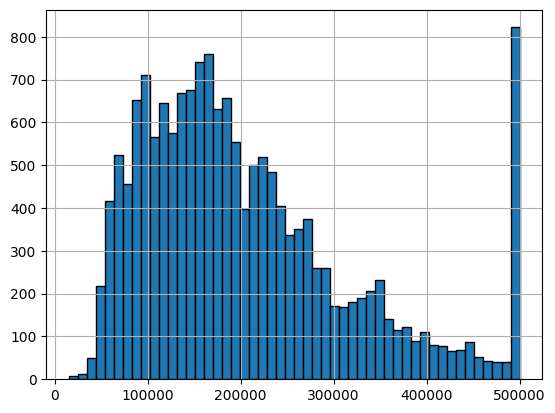

In [ ]:
# Verificación específica del posible tope en median_house_value
cap_value = housing["median_house_value"].max()
cap_count = (housing["median_house_value"] == cap_value).sum()
cap_pct = cap_count / len(housing) * 100
print(f"Registros en el tope de median_house_value ({cap_value}): {cap_count} ({cap_pct:.2f}%)")

housing["median_house_value"].hist(bins=50, edgecolor="black")

Registros en el tope de housing_median_age (52.0): 1004 (6.08%)


<Axes: >

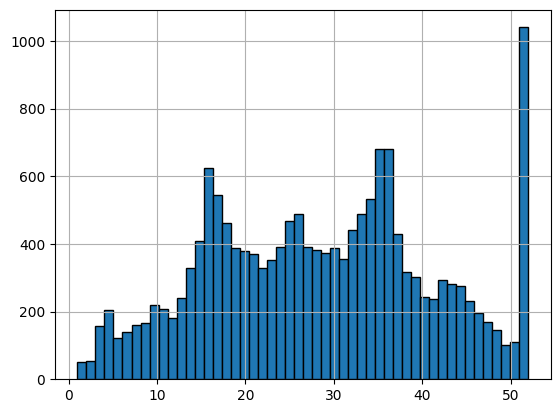

In [ ]:
# Verificación específica del posible tope en housing_median_age
cap_value = housing["housing_median_age"].max()
cap_count = (housing["housing_median_age"] == cap_value).sum()
cap_pct = cap_count / len(housing) * 100
print(f"Registros en el tope de housing_median_age ({cap_value}): {cap_count} ({cap_pct:.2f}%)")

housing["housing_median_age"].hist(bins=50, edgecolor="black")

Registros en el tope de median_income (15.0001): 34 (0.21%)


<Axes: >

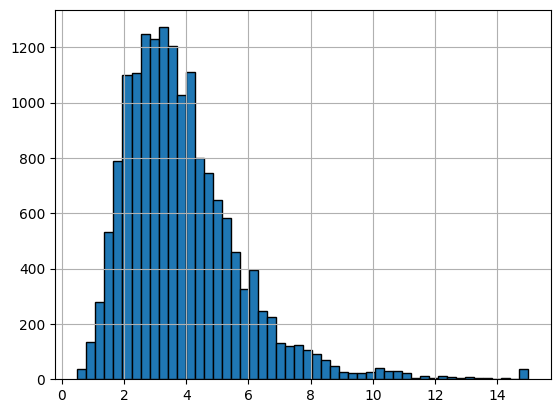

In [ ]:
# Verificación específica del posible tope en median_income
cap_value = housing["median_income"].max()
cap_count = (housing["median_income"] == cap_value).sum()
cap_pct = cap_count / len(housing) * 100
print(f"Registros en el tope de median_income ({cap_value}): {cap_count} ({cap_pct:.2f}%)")

housing["median_income"].hist(bins=50, edgecolor="black")

Se observan colas largas y valores extremos en variables de conteo (`total_rooms`, `total_bedrooms`, `population`, `households`), lo cual es esperable en datos geográficos agregados por distrito y no implica necesariamente error de captura.

Adicionalmente, `median_house_value` presenta acumulación en el valor tope (500,001), señal de censura o capping en la variable objetivo. Esto es crítico para modelado, ya que puede subestimar viviendas de alto valor real y afectar métricas en el extremo superior.

Así mismo, `housing_median_age` se ve limitado en 52 y `median_income` limitado en 15.0001 lo cual puede inducir a errores por censura o capping de la variable, especialmente en primer caso ya que representa un porcentaje alto (6.17%) mientras que el segundo no debería ser tan significativo el impacto (0.24% de registros en el límite de la variable).

### 2.2.4 Consistencia

In [ ]:
# 1) Consistencia de esquema (tipos y dominio categórico)
dtype_summary = pd.DataFrame({
    "column": housing.columns,
    "dtype": [str(housing[col].dtype) for col in housing.columns],
    "null_count": [int(housing[col].isna().sum()) for col in housing.columns]
})
display(dtype_summary)

# 2) Consistencia lógica entre variables
consistency_checks = []

def add_check(rule_name, invalid_mask):
    invalid_count = int(invalid_mask.sum())
    consistency_checks.append({
        "rule": rule_name,
        "invalid_count": invalid_count,
        "invalid_pct": round(invalid_count / len(housing) * 100, 4)
    })

# Reglas de no negatividad / positividad
add_check("total_rooms > 0", housing["total_rooms"] <= 0)
add_check("total_bedrooms >= 0 o NaN", housing["total_bedrooms"].fillna(0) < 0)
add_check("population > 0", housing["population"] <= 0)
add_check("households > 0", housing["households"] <= 0)
add_check("median_income > 0", housing["median_income"] <= 0)
add_check("median_house_value > 0", housing["median_house_value"] <= 0)

# Reglas lógicas entre variables
add_check("total_bedrooms <= total_rooms", housing["total_bedrooms"] > housing["total_rooms"])
add_check("households <= population", housing["households"] > housing["population"])

bedrooms_per_room = housing["total_bedrooms"] / housing["total_rooms"]
invalid_bedrooms_per_room = bedrooms_per_room.notna() & (
    (bedrooms_per_room < 0) | (bedrooms_per_room > 1)
    )
add_check("0 <= total_bedrooms/total_rooms <= 1", invalid_bedrooms_per_room)

persons_per_household = housing["population"] / housing["households"]
invalid_persons_per_household = persons_per_household.notna() & (persons_per_household <= 0)
add_check("population/households > 0", invalid_persons_per_household)

# Consistencia geográfica (rangos plausibles para California)
add_check("longitude entre -125 y -113", ~housing["longitude"].between(-125, -113))
add_check("latitude entre 32 y 43", ~housing["latitude"].between(32, 43))

consistency_report = pd.DataFrame(consistency_checks).sort_values(
    by=["invalid_count", "invalid_pct"], ascending=False
).reset_index(drop=True)

print("\nReporte de consistencia:")
display(consistency_report)

# Muestra de filas inconsistentes para reglas con errores
failed_rules = consistency_report[consistency_report["invalid_count"] > 0]["rule"].tolist()

if failed_rules:
    print("\nMuestras de inconsistencias detectadas:")

    if "total_bedrooms <= total_rooms" in failed_rules:
        display(
            housing.loc[housing["total_bedrooms"] > housing["total_rooms"], [
                "total_rooms", "total_bedrooms", "population", "households"
            ]].head(5)
        )

    if "households <= population" in failed_rules:
        display(
            housing.loc[housing["households"] > housing["population"], [
                "population", "households", "total_rooms", "total_bedrooms"
            ]].head(5)
        )

    if "0 <= total_bedrooms/total_rooms <= 1" in failed_rules:
        sample_ratio = housing.loc[invalid_bedrooms_per_room, [
            "total_rooms", "total_bedrooms"
        ]].head(5).copy()
        sample_ratio["bedrooms_per_room"] = (
            sample_ratio["total_bedrooms"] / sample_ratio["total_rooms"]
        )
        display(sample_ratio)
else:
    print("No se detectaron inconsistencias lógicas críticas con las reglas definidas.")

,column,dtype,null_count
0,longitude,float64,0
1,latitude,float64,0
2,housing_median_age,float64,0
3,total_rooms,float64,0
4,total_bedrooms,float64,168
5,population,float64,0
6,households,float64,0
7,median_income,float64,0
8,median_house_value,float64,0
9,ocean_proximity,object,0



Reporte de consistencia:


,rule,invalid_count,invalid_pct
0,households <= population,3,0.0182
1,total_rooms > 0,0,0.0000
2,total_bedrooms >= 0 o NaN,0,0.0000
3,population > 0,0,0.0000
4,households > 0,0,0.0000
5,median_income > 0,0,0.0000
6,median_house_value > 0,0,0.0000
7,total_bedrooms <= total_rooms,0,0.0000
8,0 <= total_bedrooms/total_rooms <= 1,0,0.0000
9,population/households > 0,0,0.0000



Muestras de inconsistencias detectadas:


,population,households,total_rooms,total_bedrooms
6419,27.0,39.0,1116.0,214.0
7162,3.0,4.0,18.0,6.0
14909,198.0,204.0,484.0,202.0


La validación de consistencia confirma que el dataset mantiene estructura de tipos adecuada. A nivel lógico entre variables, las reglas de negocio clave (`total_bedrooms <= total_rooms`, `households <= population`, y variables positivas) permiten detectar conflictos de integridad que podrían afectar el modelado. En este caso, solo se observó 3 registros con inconsistencias de inclumplimiento de `households <= population`; sin embargo, esto representa solo el 0.018% por lo que no se toma acción al respecto.

# 3. Histogramas

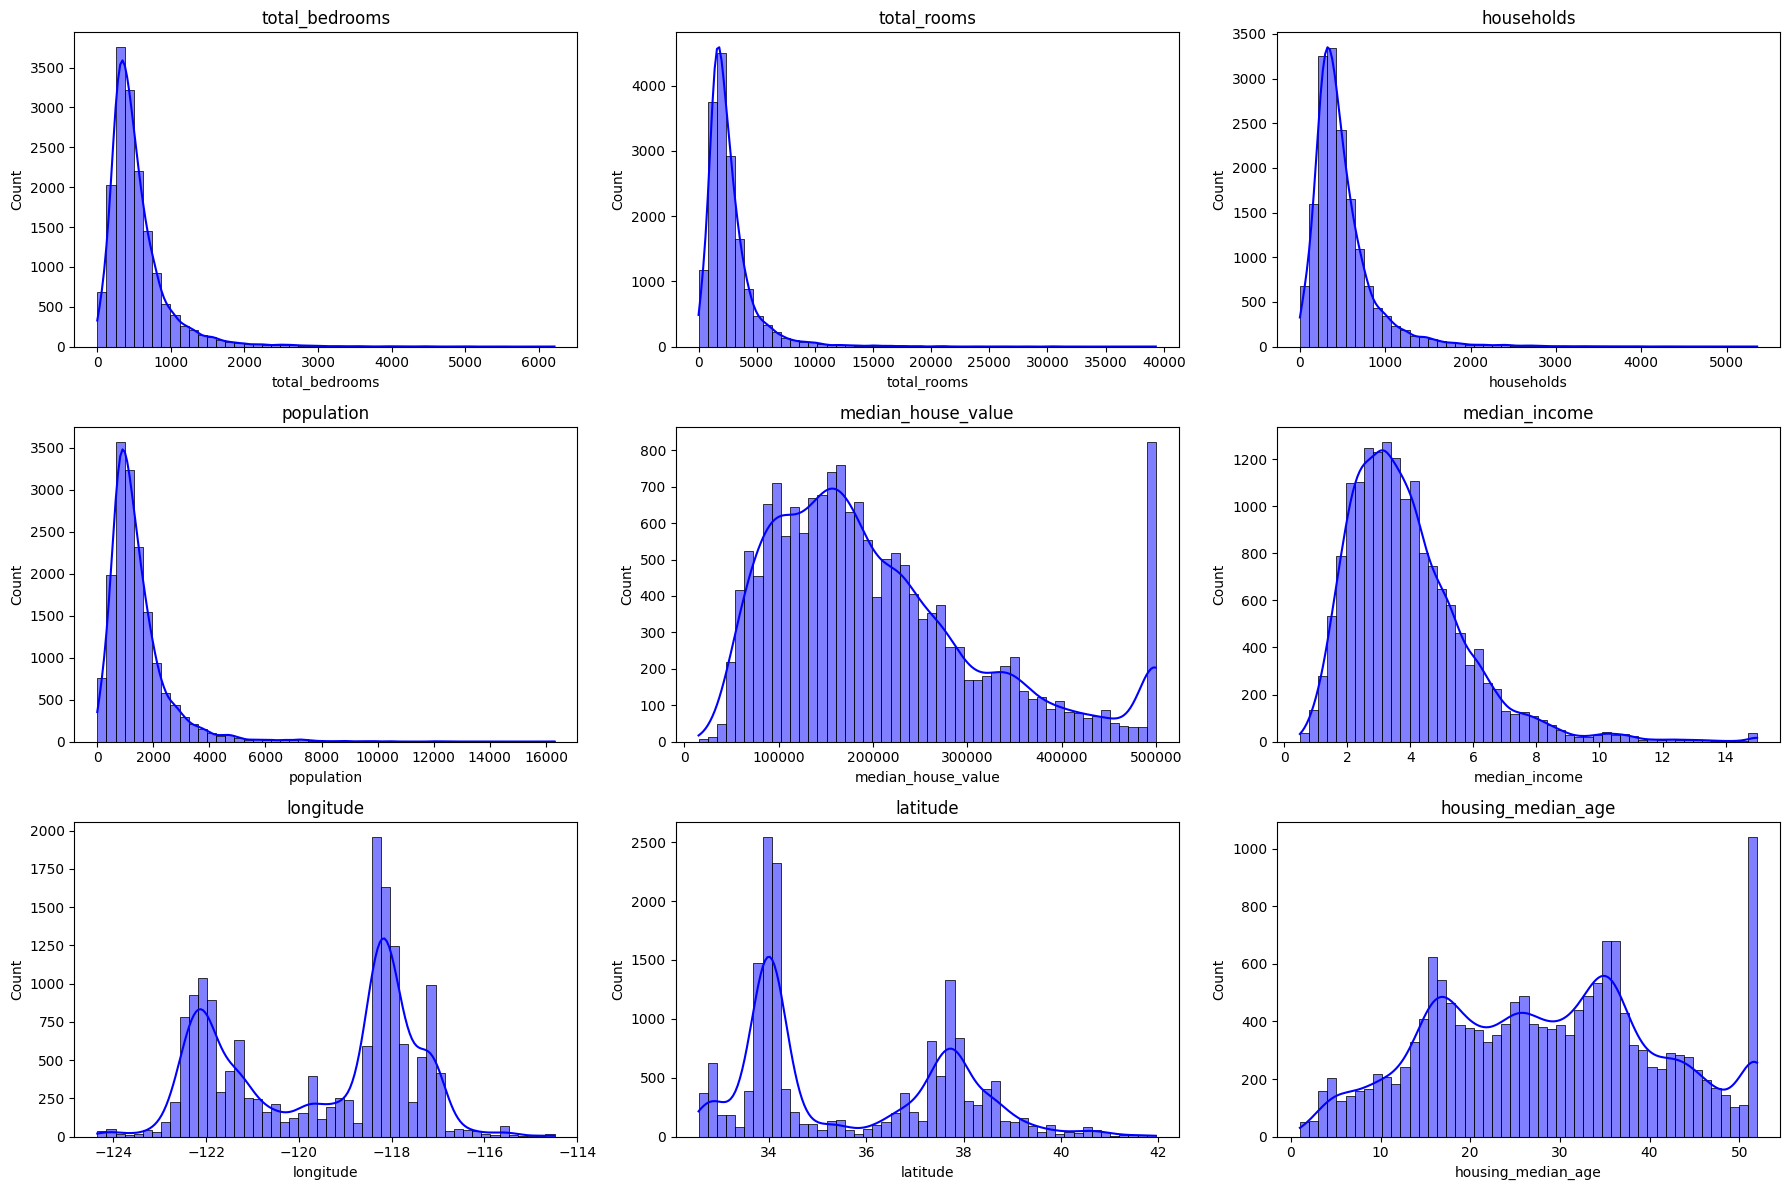

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(sensitivity_summary["column"]):
    sns.histplot(housing[col].dropna(), bins=50, kde=True, ax=axes[i], color='blue')
    axes[i].set_title(col)

# Apagar los ejes no utilizados
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

<Axes: >

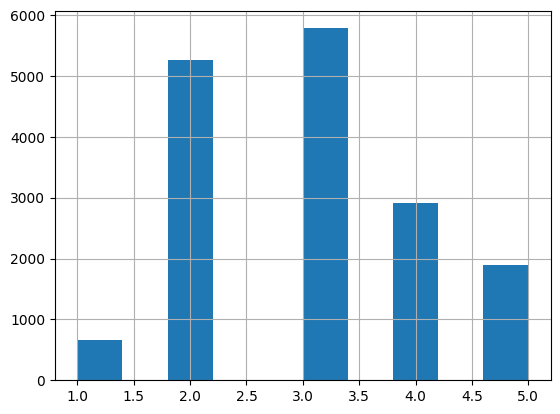

In [ ]:
# Para el Stratified Sampling basado en median_income, vemos que la mayoría de los valores se concentran entre 0 y 6, 
# con algunos valores extremos por encima de 6. Para crear categorías de ingresos, podemos usar pd.cut para dividir median_income en rangos.

income_range = pd.cut(
    housing["median_income"],
    # dividimos en 4 categorías entre 0 y 6, y una categoría adicional para valores mayores a 6
    bins=[0.0, 1.5, 3.0, 4.5, 6.0, float("inf")],
    labels=[1, 2, 3, 4, 5]
)

income_range.hist()

Se observan distribuciones con colas largas y posibles valores atípicos en varias variables numéricas, especialmente en `median_house_value`, `median_income` y `housing_median_age`. Esto sugiere la presencia de outliers que podrían influir en el análisis y modelado posterior.

# 4. Visualización Geoespacial

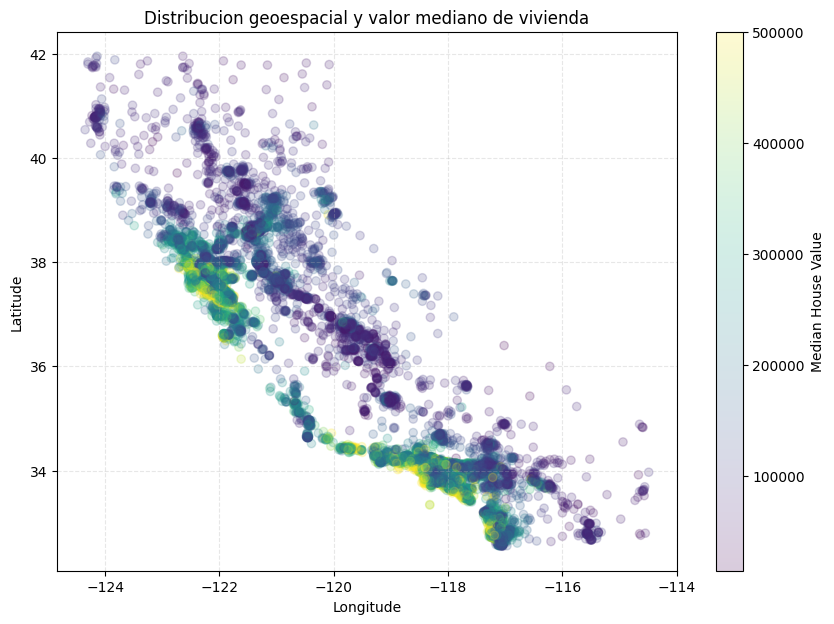

In [ ]:
# Visualizacion geoespacial: longitud vs latitud
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    housing["longitude"],
    housing["latitude"],
    alpha=0.2,
    c=housing["median_house_value"],
    cmap="viridis",
)

plt.colorbar(scatter, label="Median House Value")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribucion geoespacial y valor mediano de vivienda")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

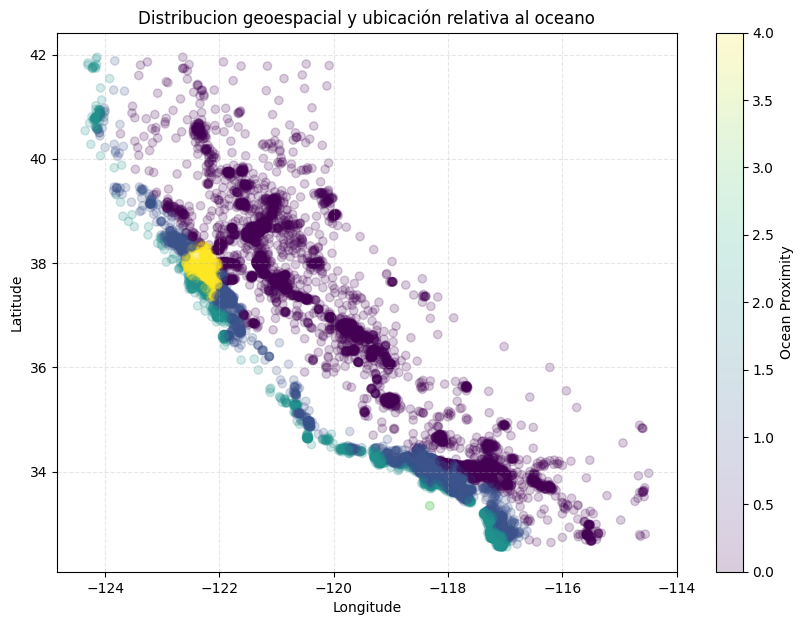

In [ ]:
# Visualizacion geoespacial: longitud vs latitud

mapping = {
    "INLAND": 0,
    "<1H OCEAN": 1,
    "NEAR OCEAN": 2,
    "ISLAND": 3,
    "NEAR BAY": 4,
}

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    housing["longitude"],
    housing["latitude"],
    alpha=0.2,
    c=housing["ocean_proximity"].map(mapping),
    cmap="viridis",
)

plt.colorbar(scatter, label="Ocean Proximity")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Distribucion geoespacial y ubicación relativa al oceano")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()

Se observa que el `median_house_value` se correlaciona directamente con la cercanía al océano o a la bahía.

# 5. Correlaciones

In [ ]:
# Matriz de correlación
corr_matrix = housing.corr(numeric_only=True)

# Correlación de cada variable con el objetivo, ordenando por el valor absoluto de la correlación
corr_with_target = corr_matrix["median_house_value"].abs().sort_values(ascending=False)

print("Correlación con median_house_value (ordenado por valor absoluto):")
print(corr_matrix["median_house_value"].loc[corr_with_target.index])

Correlación con median_house_value (ordenado por valor absoluto):
median_house_value    1.000000
median_income         0.688380
latitude             -0.139584
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
longitude            -0.050859
population           -0.020153
Name: median_house_value, dtype: float64


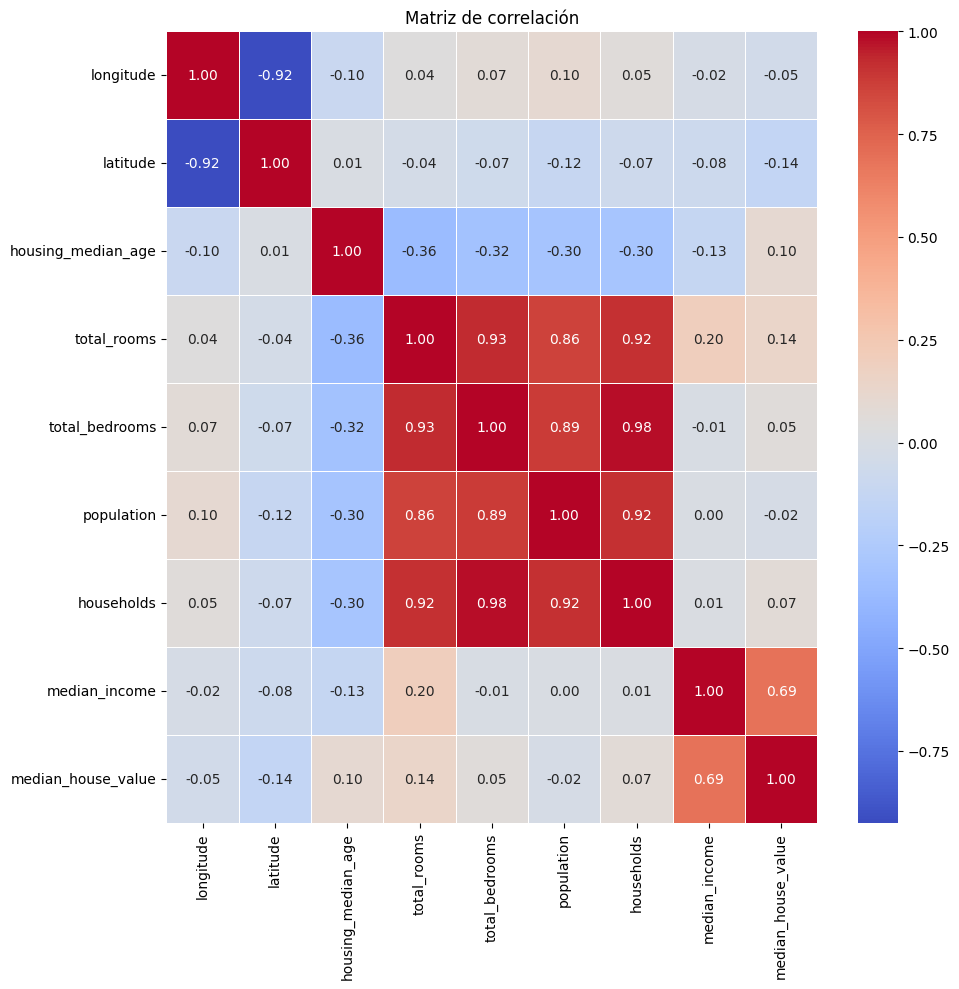

In [ ]:
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

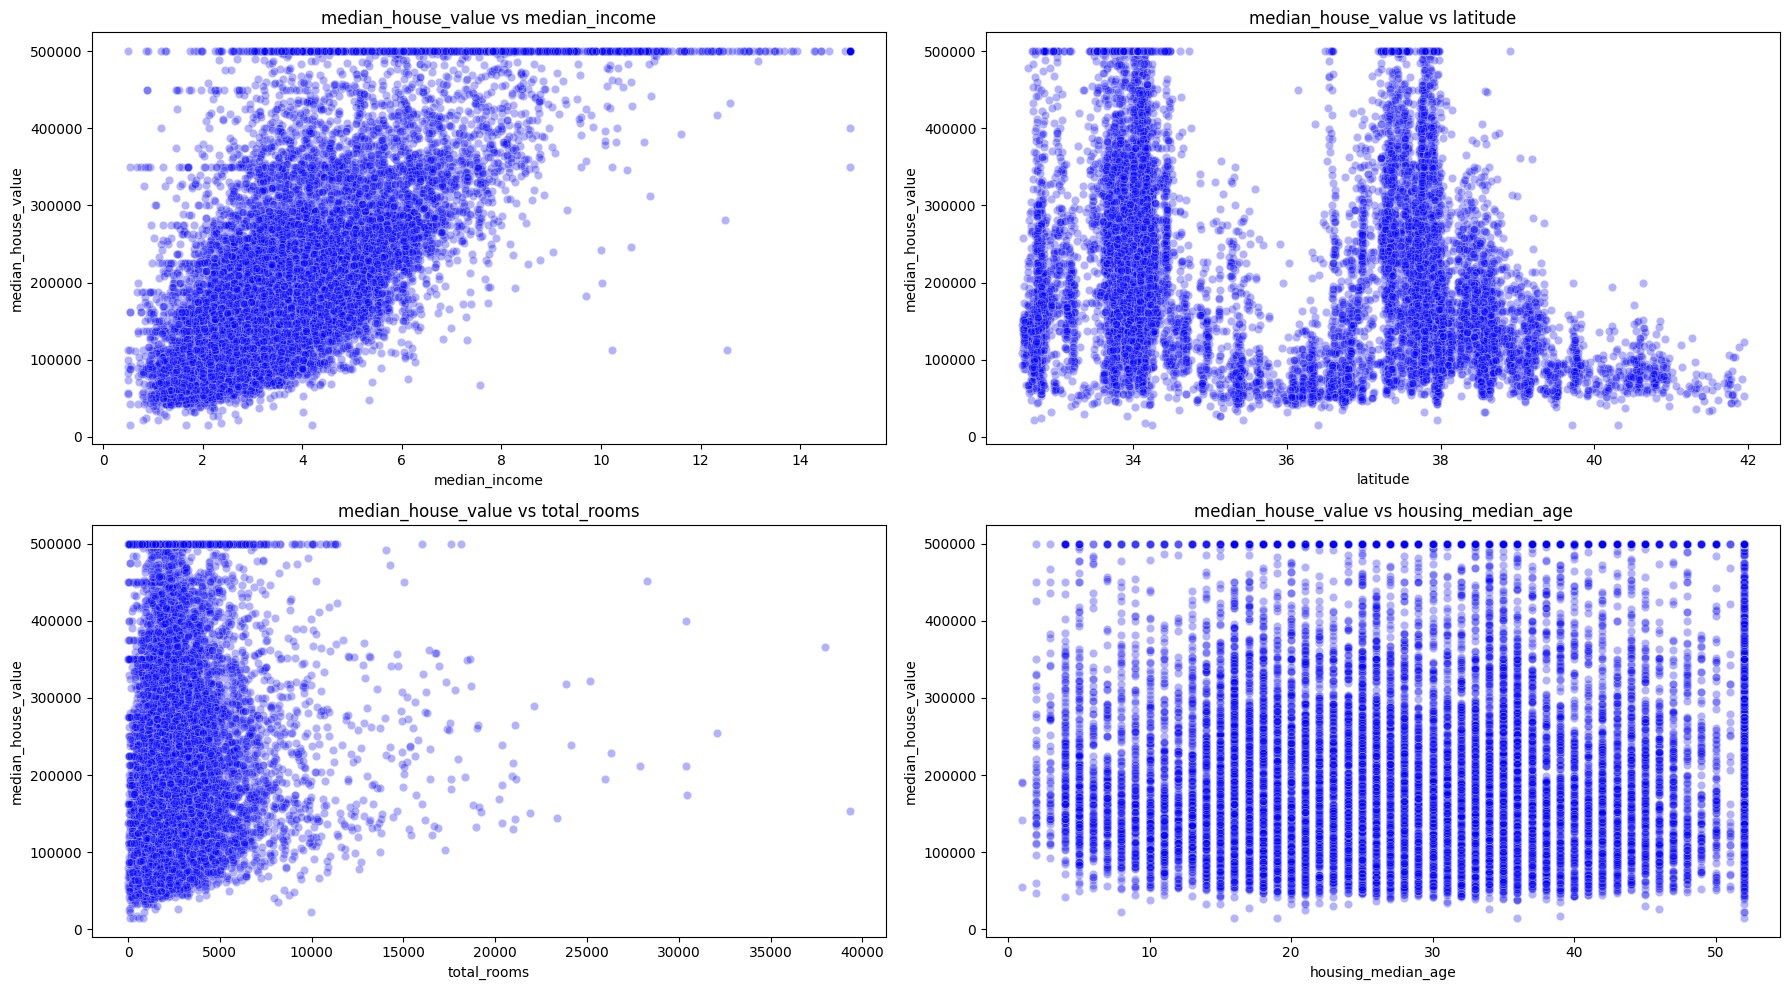

In [ ]:
# scatter plot entre median_house_value y top 3 variables correlacionadas

top_features = corr_with_target.index[1:5]  # Excluyendo median_house_value

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for i, feature in enumerate(top_features):
    row, col = divmod(i, 2)
    sns.scatterplot(
        x=housing[feature],
        y=housing["median_house_value"],
        alpha=0.3,
        ax=axes[row, col],
        color='blue'
    )
    axes[row, col].set_title(f"median_house_value vs {feature}")
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel("median_house_value")

plt.tight_layout()
plt.show()

`median_house_value` se correlaciona principalmente con `median_income`, `latitude` y `total_rooms`, indicando que depende de factores económicos, ubicación geográfica y características físicas del distrito (tamaño y densidad de viviendas).

# 6. Conclusiones

## Hallazgos Clave del Análisis Exploratorio

### 1. Calidad de Datos
- **Completitud**: El dataset presenta alta calidad con solo el 1% de valores faltantes en `total_bedrooms`, recomendándose imputación simple.
- **Precisión**: No se detectaron duplicados exactos ni errores de captura significativos.
- **Sensibilidad**: Se identificó censura en `median_house_value` (500,001 es el tope), `housing_median_age` (máximo 52) y `median_income` (máximo 15.0001), lo cual puede afectar la precisión del modelado en valores extremos.
- **Consistencia**: El esquema de datos es sólido. Solo 3 registros (0.01%) presentan inconsistencias menores de lógica de negocio.

### 2. Distribuciones y Patrones
- Las variables numéricas muestran distribuciones con colas largas, típicas de datos geográficos agregados.
- `median_house_value` presenta una acumulación notable en el valor máximo, indicando que aproximadamente el 1.4% de las viviendas están censadas en el tope.

### 3. Factores Determinantes del Valor de Vivienda
Los análisis de correlación revelan que el precio de las viviendas está principalmente influenciado por:
- **Ingresos medianos**: Factor económico preponderante
- **Latitud**: Ubicación geográfica norte-sur
- **Total de cuartos**: Tamaño y densidad de viviendas

### 4. Ventaja Competitiva: Localización
La proximidad al océano o bahía es determinante estratégico:
- Viviendas cercanas al océano/bahía alcanzan valores significativamente superiores
- Esta variable da cuenta de la geografía de California, donde las zonas costeras y de bahía son premium

### 5. Recomendaciones para Modelado
- Aplicar técnicas de tratamiento para la censura en `median_house_value` a fin de evitar subestimaciones
- Considerar transformaciones no lineales dada la naturaleza de las distribuciones
- Utilizar variables categóricas (`ocean_proximity`) como predictores clave
- El modelo debe capturar la no linealidad entre ubicación y precio